In [1]:
import pandas as pd 
import numpy as np 
from matplotlib import pyplot as plt

In [17]:
data = pd.read_csv("data_time.txt", sep = "\t", comment = "#", index_col=False)
data.set_index("Size", inplace=True)

data

,GPU,CPU
Size,,
2,0.100568,0.001903
4,0.111754,0.007708
8,0.107789,0.030449
16,0.119556,0.121401
32,0.130521,0.463585
64,0.133161,1.765640
128,0.195718,6.971750
256,0.629715,26.235700
512,2.232590,92.552800


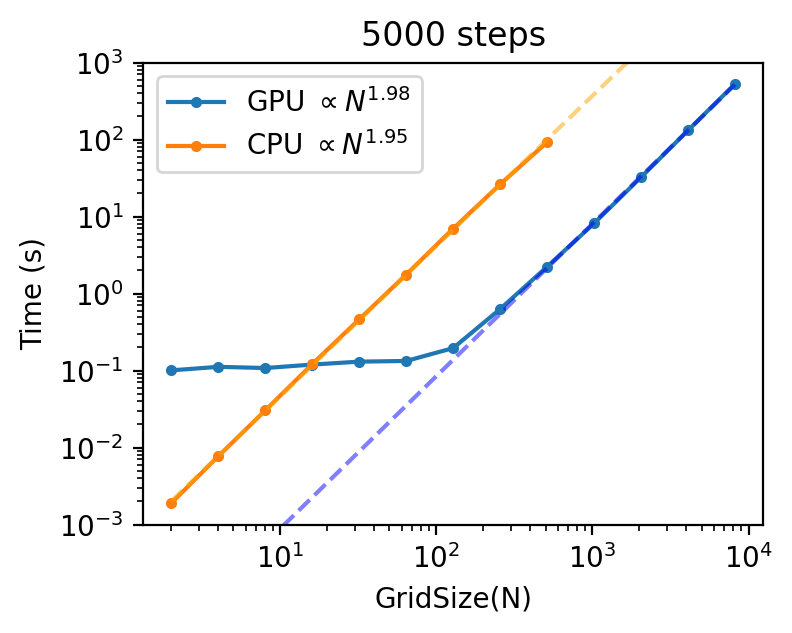

In [15]:
N = data.index.to_numpy()
gpu = data["GPU"].to_numpy()
cpu = data["CPU"].to_numpy()

# --- Remove invalid CPU values ---
cpu_mask = np.isfinite(cpu) & (cpu > 0)

# --- Logarithmic fit ---
gpu_slope, gpu_intercept = np.polyfit(np.log(N[-5:]), np.log(gpu[-5:]), 1)
cpu_slope, cpu_intercept = np.polyfit(np.log(N[cpu_mask]), np.log(cpu[cpu_mask]), 1)

# print(f"GPU fit: t = exp({gpu_intercept:.3f}) * N^{gpu_slope:.3f}")
# print(f"CPU fit: t = exp({cpu_intercept:.3f}) * N^{cpu_slope:.3f}")

# --- Generate smooth fit curves ---
N_fit = np.logspace(np.log10(N.min()), np.log10(N.max()), 200)

gpu_curve = np.exp(gpu_intercept) * N_fit**gpu_slope
cpu_curve = np.exp(cpu_intercept) * N_fit**cpu_slope

# --- Plot ---
fig, ax = plt.subplots(figsize=(4,3), dpi = 200)

exp_gpu = r"$\propto N^{"+f"{gpu_slope:.2f}"+"}$"
exp_cpu = r"$\propto N^{"+f"{cpu_slope:.2f}"+"}$"

ax.plot(N, gpu, ".-", label=f"GPU {exp_gpu}")
ax.plot(N, cpu, ".-", label=f"CPU {exp_cpu}")
ax.plot(N_fit, gpu_curve, "--", c="blue", alpha=.5)
ax.plot(N_fit, cpu_curve, "--", c="orange", alpha=.5)

ax.legend()

ax.set(xscale="log", yscale="log",
       xlabel="GridSize(N)", ylabel="Time (s)",
       title="5000 steps",
       ylim = (0.001, 1000))

plt.savefig("plt.svg")